In [68]:
from typing import List, Tuple, Union, Callable
import numpy as np
import inspect
from scipy.ndimage import rotate
import re
# import warnings
from functools import wraps
from copy import deepcopy
from itertools import compress


class Constrain:
    def __init__(self, func: Callable, *args) -> None:
        pass


class Parameter:
    """
    Classe che rappresenta un singolo parametro di un modello.

    Attributes:
        name (str): Nome del parametro.
        value (float): Valore del parametro.
        frozen (bool): Stato di congelamento del parametro.
        bounds (Tuple[float, float]): Limiti del parametro.
        description (str): Descrizione del parametro.
    """

    def __init__(
        self,
        name: str,
        value: float,
        frozen: bool = False,
        bounds: Tuple[float, float] = (-np.inf, np.inf),
        description: str = "",
    ) -> None:
        """
        Inizializza un nuovo parametro.

        Args:
            name (str): Nome del parametro.
            value (float): Valore del parametro.
            frozen (bool, opzionale): Stato di congelamento del parametro. Default è False.
            bounds (Tuple[float, float], opzionale): Limiti del parametro. Default è (-inf, inf).
            description (str, opzionale): Descrizione del parametro. Default è "".

        Raises:
            TypeError: Se i tipi degli argomenti non sono corretti.
            ValueError: Se i valori degli argomenti non sono validi.
        """
        ParameterValidator.validate_name(name)
        ParameterValidator.validate_bounds(bounds)
        ParameterValidator.validate_value_in_bounds(value, bounds)

        self._name = name
        self._value = value
        self._frozen = frozen
        self._bounds = bounds
        self._description = description

    @property
    def name(self) -> str:
        """
        Ritorna il nome del parametro.

        Returns:
            str: Nome del parametro.
        """
        return self._name

    @name.setter
    def name(self, new_name: str) -> None:
        """
        Imposta un nuovo nome per il parametro.

        Args:
            new_name (str): Nuovo nome del parametro.

        Raises:
            TypeError: Se il nuovo nome non è una stringa.
        """
        ParameterValidator.validate_name(new_name)
        self._name = new_name

    @property
    def value(self) -> float:
        """
        Ritorna il valore del parametro.

        Returns:
            float: Valore del parametro.
        """
        return self._value

    @value.setter
    def value(self, new_value: float) -> None:
        """
        Imposta un nuovo valore per il parametro.

        Args:
            new_value (float): Nuovo valore del parametro.

        Raises:
            ValueError: Se il parametro è congelato o il nuovo valore è fuori dai limiti.
        """
        if self._frozen:
            raise ValueError(
                f"Parametro {self._name} è congelato! Il nuovo valore non può essere impostato."
            )
        ParameterValidator.validate_value_in_bounds(new_value, self._bounds)
        self._value = new_value

    @property
    def bounds(self) -> Tuple[float, float]:
        """
        Ritorna i limiti del parametro.

        Returns:
            Tuple[float, float]: Limiti del parametro.
        """
        return self._bounds

    @bounds.setter
    def bounds(self, new_bounds: Tuple[float, float]) -> None:
        """
        Imposta nuovi limiti per il parametro.

        Args:
            new_bounds (Tuple[float, float]): Nuovi limiti del parametro.

        Raises:
            TypeError: Se i nuovi limiti non sono una tupla di due elementi.
            ValueError: Se i nuovi limiti non sono validi.
        """
        ParameterValidator.validate_bounds(new_bounds)
        ParameterValidator.validate_value_in_bounds(self._value, new_bounds)
        self._bounds = new_bounds

    @property
    def frozen(self) -> bool:
        """
        Ritorna lo stato di congelamento del parametro.

        Returns:
            bool: True se il parametro è congelato, False altrimenti.
        """
        return self._frozen

    @frozen.setter
    def frozen(self, is_true: bool) -> None:
        """
        Imposta lo stato di congelamento del parametro.

        Args:
            is_true (bool): Stato di congelamento del parametro.

        Raises:
            TypeError: Se il valore non è un booleano.
        """
        ParameterValidator.validate_frozen(is_true)
        self._frozen = is_true

    @property
    def description(self) -> str:
        """
        Ritorna la descrizione del parametro.

        Returns:
            str: Descrizione del parametro.
        """
        return self._description

    @description.setter
    def description(self, str: str) -> None:
        """
        Imposta una nuova descrizione per il parametro.

        Args:
            str (str): Nuova descrizione del parametro.

        Raises:
            TypeError: Se la descrizione non è una stringa.
        """
        ParameterValidator.validate_description(str)
        self._description = str

    def copy(self) -> "Parameter":
        """
        Ritorna una copia del parametro.

        Returns:
            Parameter: Copia del parametro.
        """
        return deepcopy(self)

    def __len__(self) -> int:
        """
        Ritorna la lunghezza del parametro (sempre 1).

        Returns:
            int: Lunghezza del parametro.
        """
        return 1

    def __iter__(self):
        """
        Ritorna un iteratore per il parametro.

        Returns:
            Iterator: Iteratore per il parametro.
        """
        return iter(
            [self._name, self._value, self._frozen, self._bounds, self._description]
        )

    def __getitem__(self, key):
        """
        Ritorna l'attributo specificato del parametro.

        Args:
            key (str): Nome dell'attributo.

        Returns:
            Any: Valore dell'attributo.
        """
        return getattr(self, key)

    def __setitem__(self, key, value) -> None:
        """
        Imposta l'attributo specificato del parametro.

        Args:
            key (str): Nome dell'attributo.
            value (Any): Valore da assegnare all'attributo.
        """
        setattr(self, key, value)

    def __str__(self) -> str:
        """
        Ritorna una rappresentazione testuale del parametro.

        Returns:
            str: Rappresentazione testuale del parametro.
        """
        total_string = f"PARAM NAME: {self.name}\n"
        total_string += "_" * 100 + "\n"
        total_string += f"{'NOME':<15} {'VALORE':<10} {'FREEZE':<10} {'BOUNDS':<20} {'DESCRIZIONE':<20} \n"
        total_string += "_" * 100 + "\n"

        value_str = f"{self._value:.5g}"
        bounds_str = f"({self._bounds[0]:.5g}, {self._bounds[1]:.5g})"
        total_string += f"{self.name:<15} {value_str:<10} {self._frozen:<10} {bounds_str:<20} {self.description:<20} \n"
        return total_string


class ParameterValidator:
    """
    Classe per la gestione della validazione di parametri singoli.
    """

    @staticmethod
    def validate_name(name: str) -> None:
        """
        Valida il nome del parametro.

        Args:
            name (str): Nome del parametro.

        Raises:
            TypeError: Se il nome non è una stringa.
        """
        if not isinstance(name, str):
            raise TypeError("Il nome del parametro deve essere una stringa!")

    @staticmethod
    def validate_bounds(bounds: Tuple[float, float]) -> None:
        """
        Valida i limiti del parametro.

        Args:
            bounds (Tuple[float, float]): Limiti del parametro.

        Raises:
            TypeError: Se i limiti non sono una tupla di due elementi.
            ValueError: Se i limiti non sono validi.
        """
        if not isinstance(bounds, (list, np.ndarray, tuple)):
            raise TypeError(
                f"New bounds must be in form of iterable, you gave {type(bounds)}"
            )
        if len(bounds) != 2:
            raise ValueError("I limiti devono essere una tupla con due elementi.")
        if not bounds[0] <= bounds[1]:
            raise ValueError(
                "Il limite inferiore deve essere minore o uguale al limite superiore."
            )

    @staticmethod
    def validate_value_in_bounds(value: float, bounds: Tuple[float, float]) -> None:
        """
        Valida che il valore del parametro sia entro i limiti specificati.

        Args:
            value (float): Valore del parametro.
            bounds (Tuple[float, float]): Limiti del parametro.

        Raises:
            TypeError: Se il valore non è un numero.
            ValueError: Se il valore è fuori dai limiti.
        """
        if not isinstance(value, (int, float)):
            raise TypeError("Value must be of type Number, not ", type(value))
        if not bounds[0] <= value <= bounds[1]:
            raise ValueError(f"Il valore {value} è fuori dai limiti {bounds}")

    @staticmethod
    def validate_frozen(is_true: bool) -> None:
        """
        Valida lo stato di congelamento del parametro.

        Args:
            is_true (bool): Stato di congelamento del parametro.

        Raises:
            TypeError: Se il valore non è un booleano.
        """
        if not isinstance(is_true, bool):
            raise TypeError(
                f'Il valore di "frozen" può essere solo True o False, hai fornito {is_true, type(is_true)}'
            )

    @staticmethod
    def validate_description(strg: str) -> None:
        """
        Valida la descrizione del parametro.

        Args:
            strg (str): Descrizione del parametro.

        Raises:
            TypeError: Se la descrizione non è una stringa.
        """
        if not isinstance(strg, str):
            raise TypeError("Description must be a string!")


# Esempio di utilizzo
param1 = Parameter(
    name="param1", value=10.0, bounds=(0, 20), description="Parametro di esempio"
)
print(param1)

# Cambiare il valore del parametro
param1.value = 15.0
print(param1)

# Tentare di cambiare il valore di un parametro congelato
param1.frozen = True
try:
    param1.value = 5.0
except ValueError as e:
    print(e)

# Creare una copia del parametro
param2 = param1.copy()
param2.frozen = False
param2.name = "param2"
param2.value = 18.0
print(param2)

# Esempio di utilizzo

PARAM NAME: param1
____________________________________________________________________________________________________
NOME            VALORE     FREEZE     BOUNDS               DESCRIZIONE          
____________________________________________________________________________________________________
param1          10         0          (0, 20)              Parametro di esempio 

PARAM NAME: param1
____________________________________________________________________________________________________
NOME            VALORE     FREEZE     BOUNDS               DESCRIZIONE          
____________________________________________________________________________________________________
param1          15         0          (0, 20)              Parametro di esempio 

Parametro param1 è congelato! Il nuovo valore non può essere impostato.
PARAM NAME: param2
____________________________________________________________________________________________________
NOME            VALORE     FREEZE     BO

In [69]:
from typing import Tuple


class Constant(Parameter):
    def __init__(
        self,
        name: str,
        value: float,
        frozen: bool = True,
        bounds: Tuple[float, float] = (-np.inf, np.inf),
        description: str = "",
    ) -> None:
        super().__init__(name, value, frozen, bounds, description)

    @Parameter.value.setter
    def value(self, new_value: float) -> None:
        raise AttributeError("Cannot modify the value of a Constant.")

    @Parameter.bounds.setter
    def bounds(self, new_bounds: Tuple[float, float]) -> None:
        raise AttributeError("Cannot modify the bounds of a Constant.")

    @Parameter.frozen.setter
    def frozen(self, is_true: bool) -> None:
        raise AttributeError("Cannot modify the frozen state of a Constant.")


aa = Constant("c", 2)

print(aa)

PARAM NAME: c
____________________________________________________________________________________________________
NOME            VALORE     FREEZE     BOUNDS               DESCRIZIONE          
____________________________________________________________________________________________________
c               2          1          (-inf, inf)                               



In [70]:
test = Parameter('str', 22, bounds=(2,22), frozen=True, description='test creazione')
test.frozen = False
test['name'] = 'test'
test.value = 3
test.bounds = (1,43)
print(test)



PARAM NAME: test
____________________________________________________________________________________________________
NOME            VALORE     FREEZE     BOUNDS               DESCRIZIONE          
____________________________________________________________________________________________________
test            3          0          (1, 43)              test creazione       



In [71]:
from typing import  Tuple, Dict


def cached_property(func):
    """Cacha la proprietà così da rendere il calcolo più veloce."""

    @property
    @wraps(func)
    def wrapper(self):
        if not hasattr(self, "_cache"):
            self._cache = {}  # Inizializza il cache se non esiste
        if func.__name__ not in self._cache:
            self._cache[func.__name__] = func(self)  # Calcola e memorizza il risultato
        return self._cache[func.__name__]  # Ritorna il valore memorizzato

    return wrapper



class ParameterHandler:
    """
    Classe che gestisce un insieme di parametri per un modello.

    Attributes:
        _parameters (Dict[str, Parameter]): Dizionario dei parametri.
        _is_inside_model (bool): Indica se il gestore è stato aggiunto a un modello.
    """

    def __init__(self, parameters: Union[Parameter, List[Parameter]] = None) -> None:
        """
        Inizializza il gestore dei parametri.

        Args:
            parameters (Union[Parameter, List[Parameter]], opzionale): Un singolo parametro o una lista di parametri.
        """
        self._parameters = {}
        self._is_inside_model = (
            False  # Una volta dentro modello non posso aggiungere parametri
        )
        if isinstance(parameters, Parameter):
            self._add_parameter(parameters)
        elif isinstance(parameters, list):
            for param in parameters:
                self._add_parameter(param)
        elif parameters is None:
            pass
        else:
            raise TypeError(
                "Parameters must be of type Parameter or List[Parameter]",
                type(parameters),
            )

    def _assign_attribute(self, items: Union[List, Dict], attribute: str) -> None:
        """
        Assegna un valore a un attributo dei parametri non congelati.

        Args:
            items (Union[List, Dict]): Valori da assegnare (lista o dizionario).
            attribute (str): Nome dell'attributo da assegnare.

        Raises:
            ValueError: Se il numero di elementi nella lista non corrisponde al numero di parametri liberi.
            TypeError: Se items non è né una lista né un dizionario.
        """
        if isinstance(items, (list, np.ndarray)):
            if len(items) != self.n_free_params:
                raise ValueError(
                    f"Number of items {len(items)} must match number of free parameters! {self.n_free_params}"
                )
            for param, val in zip(self.free_parameters, items):
                setattr(param, attribute, val)
        elif isinstance(items, dict):
            for name, val in items.items():
                setattr(self[name], attribute, val)
        else:
            raise TypeError("Items must be a list or dictionary")

    def _map_names_to_indices(self, key: str) -> int:
        """
        Mappa il nome di un parametro al corrispondente indice.

        Args:
            key (str): Nome del parametro.

        Returns:
            int: Indice del parametro.

        Raises:
            KeyError: Se il nome del parametro non è trovato.
        """
        try:
            return list(self._parameters.keys()).index(key)
        except ValueError:
            raise KeyError(f"Key '{key}' not found in the dictionary")

    def _map_indices_to_names(self, index: int) -> str:
        """
        Mappa l'indice di un parametro al corrispondente nome.

        Args:
            index (int): Indice del parametro.

        Returns:
            str: Nome del parametro.

        Raises:
            IndexError: Se l'indice è fuori dai limiti.
        """
        keys = list(self._parameters.keys())
        if index < 0 or index >= len(keys):
            raise IndexError(f"Index '{index}' is out of bounds for the dictionary")
        return keys[index]

    def _invalidate_cache(self) -> None:
        """
        Invalida la cache dei parametri.
        """
        if hasattr(self, "_cache"):
            del self._cache

    def _is_frozen(self, parameter: Parameter) -> bool:
        """
        Verifica se un parametro è congelato.

        Args:
            parameter (Parameter): Il parametro da verificare.

        Returns:
            bool: True se il parametro è congelato, False altrimenti.
        """
        return parameter.frozen

    def _is_not_frozen(self, parameter: Parameter) -> bool:
        """
        Verifica se un parametro non è congelato.

        Args:
            parameter (Parameter): Il parametro da verificare.

        Returns:
            bool: True se il parametro non è congelato, False altrimenti.
        """
        return not parameter.frozen

    @cached_property
    def parameters_values(self) -> List[float]:
        """
        Ritorna i valori dei parametri.

        Returns:
            List[float]: Lista dei valori dei parametri.
        """
        return [p.value for p in self]

    @cached_property
    def parameters_names(self) -> List[str]:
        """
        Ritorna i nomi dei parametri.

        Returns:
            List[str]: Lista dei nomi dei parametri.
        """
        return [p.name for p in self]

    @cached_property
    def parameters_bounds(self) -> List[Tuple[float, float]]:
        """
        Ritorna i limiti dei parametri.

        Returns:
            List[Tuple[float, float]]: Lista dei limiti dei parametri.
        """
        return [p.bounds for p in self]

    @cached_property
    def n_free_params(self) -> int:
        """
        Ritorna il numero di parametri liberi.

        Returns:
            int: Numero di parametri liberi.
        """
        return len(self.free_parameters)

    @cached_property
    def free_parameters(self) -> List[Parameter]:
        """
        Ritorna solo i parametri liberi.

        Returns:
            List[Parameter]: Lista dei parametri liberi.
        """
        return [p for p in self if p.frozen is False]

    @cached_property
    def frozen_parameters(self) -> List[Parameter]:
        """
        Ritorna solo i parametri congelati.

        Returns:
            List[Parameter]: Lista dei parametri congelati.
        """
        return [p for p in self if p.frozen is True]

    def set_values(self, values: Union[List, Dict]) -> None:
        """
        Imposta i valori dei parametri non congelati.

        Args:
            values (Union[List, Dict]): Valori da assegnare (lista o dizionario).
        """
        self._assign_attribute(values, "value")

    def set_bounds(self, bounds: Union[List, Dict]) -> None:
        """
        Imposta i limiti dei parametri non congelati.

        Args:
            bounds (Union[List, Dict]): Limiti da assegnare (lista o dizionario).
        """
        self._assign_attribute(bounds, "bounds")

    def set_frozen(self, is_frozen: Union[List, Dict]) -> None:
        """
        Imposta lo stato di congelamento dei parametri.

        Args:
            is_frozen (Union[List, Dict]): Stato di congelamento da assegnare (lista o dizionario).
        """
        self._assign_attribute(is_frozen, "frozen")

    def _add_parameter(self, parameter: Parameter) -> None:
        """
        Aggiunge un parametro al gestore.

        Args:
            parameter (Parameter): Il parametro da aggiungere.

        Raises:
            ValueError: Se il parametro esiste già o se si tenta di aggiungere un parametro dopo la creazione del modello.
        """
        if self._is_inside_model:
            raise ValueError(
                f"Cannot add parameter {parameter.name} to model after the creation"
            )
        if parameter.name in self._parameters:
            raise ValueError(f"Parameter {parameter.name} already exists.")
        self._parameters[parameter.name] = parameter
        self._invalidate_cache()

    def _get_parameter(self, name: str) -> Parameter:
        """
        Ritorna un parametro dal gestore.

        Args:
            name (str): Nome del parametro.

        Returns:
            Parameter: Il parametro richiesto.

        Raises:
            ValueError: Se il parametro non è trovato.
        """
        if name not in self._parameters:
            raise ValueError(f"Parameter {name} not found.")
        return self._parameters[name]

    def __getitem__(self, name: str) -> Parameter:
        """
        Ritorna un parametro usando l'operatore di accesso a dizionario.

        Args:
            name (str): Nome del parametro.

        Returns:
            Parameter: Il parametro richiesto.
        """
        return self._get_parameter(name)

    def __contains__(self, key: str) -> bool:
        """
        Verifica se un parametro è presente usando il suo nome.

        Args:
            key (str): Nome del parametro.

        Returns:
            bool: True se il parametro è presente, False altrimenti.
        """
        return key in self._parameters

    def __iter__(self):
        """
        Itera sui parametri.

        Returns:
            Iterator: Iteratore sui parametri.
        """
        return iter(self._parameters.values())

    def __len__(self) -> int:
        """
        Ritorna il numero di parametri.

        Returns:
            int: Numero di parametri.
        """
        return len(self._parameters)

    def items(self):
        """
        Ritorna gli elementi del gestore come coppie chiave-valore.

        Returns:
            ItemsView: Vista degli elementi del gestore.
        """
        return self._parameters.items()


# Esempi di utilizzo
p1 = Parameter(name="param1", value=5.0, bounds=(0.0, 10.0), frozen=True)
p2 = Parameter(name="param2", value=7.0, bounds=(0.0, 10.0))

handler = ParameterHandler([p1, p2])

print(handler.parameters_names)  # ['param1', 'param2']
print(handler.parameters_values)  # [5.0, 7.0]
print(handler.n_free_params)  # 1
print(
    handler.free_parameters
)  # [<Parameter name='param2', value=7.0, bounds=(0.0, 10.0), frozen=False>]
print(
    handler.frozen_parameters
)  # [<Parameter name='param1', value=5.0, bounds=(0.0, 10.0), frozen=True>]

handler.set_values({"param2": 8.0})
print(handler.parameters_values)  # [5.0, 8.0]

handler.set_bounds({"param2": (0.0, 15.0)})
print(handler.parameters_bounds)  # [(0.0, 10.0), (0.0, 15.0)]

handler.set_frozen({"param2": True})
print(
    handler.frozen_parameters
)  # [<Parameter name='param1', value=5.0, bounds=(0.0, 10.0), frozen=True>, <Parameter name='param2', value=8.0, bounds=(0.0, 15.0), frozen=True>]

['param1', 'param2']
[5.0, 7.0]
1
[5.0, 7.0]
[(0.0, 10.0), (0.0, 15.0)]


In [72]:
def calcola_dimensioni(lista):
    # Variabili di controllo per la sequenza
    dimensioni = 0
    if lista[0] == "x" and lista[1] != "y":
        dimensioni += 1
    elif lista[0] == "x" and lista[1] == "y" and lista[2] != "z":
        dimensioni += 2
    elif lista[0] == "x" and lista[1] == "y" and lista[2] == "z":
        dimensioni += 3

    return dimensioni


class ModelMeta(type):
    def __new__(cls, name, bases, dct, **kwargs):
        """
        Crea una nuova classe modello con attributi specifici.

        Parameters:
        -----------
        name : str
            Nome della classe.
        bases : tuple
            Basi della classe.
        dct : dict
            Dizionario degli attributi della classe.
        kwargs : dict
            Argomenti aggiuntivi.

        Returns:
        --------
        type
            Nuova classe tipo.
        """
        new_cls = super().__new__(cls, name, bases, dct, **kwargs)
        _param_names = []
        
        if name == "ModelMeta":
            return new_cls

        _param_dict = ParameterHandler()

        _n_dim: int = getattr(new_cls, "N_DIMENSIONS", 0)
        _n_inputs: int = getattr(new_cls, "N_INPUTS", 0)
        _n_outputs: int = getattr(
            new_cls, "N_OUTPUTS", 1
        )  # default è avere 1 outputs ovviamente
        _is_composite: bool = getattr(new_cls, "IS_COMPOSITE", False)

        if "evaluate" in dct and not _is_composite:
            _param_names, _param_default, _is_constant = cls._extract_params(
                dct["evaluate"]
            )

            # controllo se tra i primi 3 ci sono 'x', 'y', 'z' in questa sucessione
            # se e solo se _n_inpputs, _n_outputs e _n_dim sono tutti 0
            if _n_dim == 0 and _n_inputs == 0 and _n_outputs == 1:
                _n_dim = calcola_dimensioni(_param_names)
                _n_inputs = calcola_dimensioni(_param_names)

            for _name, _val, _const in zip(
                _param_names[_n_inputs:],
                _param_default[_n_inputs:],
                _is_constant[_n_inputs:],
            ):
                _param_dict._add_parameter(Parameter(_name, _val, frozen=_const))

        new_cls._param_dict = _param_dict
        new_cls._n_inputs = _n_inputs
        new_cls._n_outputs = _n_outputs
        new_cls._name = name
        new_cls._is_composite = _is_composite
        new_cls._n_dim = _n_dim
        new_cls._grid = _param_names[:_n_inputs] if _param_names else []

        return new_cls

    def __init__(cls, name, bases, dct, **kwargs):
        """
        Inizializza una nuova classe modello.

        Parameters:
        -----------
        name : str
            Nome della classe.
        bases : tuple
            Basi della classe.
        dct : dict
            Dizionario degli attributi della classe.
        kwargs : dict
            Argomenti aggiuntivi.
        """
        super().__init__(name, bases, dct, **kwargs)

    def __call__(self, *args, **kwargs):
        """
        Crea una nuova istanza del modello.

        Parameters:
        -----------
        args : tuple
            Argomenti posizionali.
        kwargs : dict
            Argomenti keyword.

        Returns:
        --------
        instance
            Nuova istanza del modello.
        """
        instance = super().__call__(*args, **kwargs)

        IGNORE_KWARGS = ["name", "parameters"]

        name = kwargs.get("name", instance._name)

        # trovare un modo per differenziare kwargs da nome del metodo initi

        # if "parameters" in instance.__dict__ and not instance._is_composite:
        #    param_dict = instance.__dict__["parameters"]
        # else:
        #    param_dict = deepcopy(instance._param_dict)
        param_dict = deepcopy(instance._param_dict)

        if "parameters" in kwargs and not instance._is_composite:
            self._validate_parameters(
                kwargs["parameters"], param_dict, instance._param_dict
            )

        # possibile errore; che succede se do lo stesso parametro come 'parameters' e kwargs?
        # per ora vincono le kwargs
        for p_name in kwargs:
            if p_name in IGNORE_KWARGS:
                continue

            if p_name in param_dict:
                param_dict[p_name].value = kwargs[p_name]
            else:
                raise ValueError(f"key {p_name} is not a parameter for the model!")

        if not instance._is_composite:
            instance._parameters = param_dict
            instance._parameters_names = list(param_dict)

            instance.n_dim = instance._n_dim
            instance.n_inputs = instance._n_inputs
            instance.n_outputs = instance._n_outputs
            #instance.wrapped_call = self.wrapped_call(instance.evaluate, param_dict)

        instance.name = name
        instance._parameters._is_inside_model = True
        instance._grid_variables = instance._grid
        # print(type(param_dict)) ok è ParameterHandler
        if hasattr(instance, "__post_init__"):
            # Piccolo rant personale: se il me del futuro dovesse modificare qualcosa
            # e questa call non dovesse essere più giusta allora posso anche uccidermi (LOL)
            # __init__ della metaclasse non finisce nel __init__ del istanza e quindi devo
            # baipassarlo per cachare la call iniziale per permettere al modello di essere creato
            # e chiamato subito con dei parametri freezati
            instance.__post_init__()
            # btw il __post_init__ può essere usato da CompositeModel anche
        return instance

    @staticmethod
    def _extract_params(method):
        """
        Estrae i nomi e i valori di default dei parametri dal metodo evaluate.

        Parameters:
        -----------
        method : function
            Metodo evaluate della classe.

        Returns:
        --------
        tuple
            Lista dei nomi dei parametri e lista dei valori di default.
        """
        signature = inspect.signature(method)
        params = {}
        is_constant = []
        for param_name, param in signature.parameters.items():
            if param_name != "self":
                if param.default is inspect.Parameter.empty:
                    params[param_name] = 1

                    is_constant.append(False)
                else:
                    params[param_name] = param.default
                    is_constant.append(True)
        return list(params.keys()), list(params.values()), is_constant

    @staticmethod
    def wrapped_call(func: Callable, _parameters: ParameterHandler):
        """Genera la call dei parametri congelati."""
        freeze_params = {p.name: p.value for p in _parameters if p.frozen is True}
        frozen_param_names = freeze_params.keys()
        free_param_names = [p.name for p in _parameters if not p.frozen]

        def wrapped_evaluate(*args, **kwargs):
            # Controlla se kwargs contiene parametri congelati
            for key in kwargs:
                if key in frozen_param_names:
                    raise ValueError(
                        f"Il parametro '{key}' è congelato e non può essere fornito nelle kwargs."
                    )

            # Mappa args e kwargs ai parametri non congelati
            if len(args) > len(free_param_names):
                raise ValueError(
                    "Il numero di args forniti è maggiore del numero di parametri liberi."
                )

            free_params = dict(zip(free_param_names, args))
            free_params.update(kwargs)

            # Unisci con i parametri congelati
            all_params = {**freeze_params, **free_params}

            # Prepara gli argomenti posizionali per la funzione evaluate
            positional_args = [
                all_params[name] for name in _parameters.parameters_names
            ]

            return func(*positional_args)

        return wrapped_evaluate

    def _validate_parameters(
        self,
        parameters,
        param_dict: ParameterHandler,
        class_param_dict: ParameterHandler,
    ):
        """
        Valida e aggiorna i parametri forniti.

        Parameters:
        -----------
        parameters : list
            Lista di parametri.
        param_dict : dict
            Dizionario dei parametri dell'istanza.
        class_param_dict : dict
            Dizionario dei parametri della classe.

        Raises:
        -------
        TypeError
            Se un parametro non è un'istanza di Parameter.
        ValueError
            Se un parametro non può essere aggiunto durante la creazione della classe.
        """
        if not isinstance(param_dict, ParameterHandler) and not isinstance(
            class_param_dict, ParameterHandler
        ):
            raise TypeError("Questo errore non dovrebbe accadere")
        for param in parameters:
            if not isinstance(param, Parameter):
                raise TypeError(
                    "Initial Parameters for the model must be instances of Parameter"
                )
            if param.name in class_param_dict:
                param_dict[param.name].name = param.name
                param_dict[param.name].value = param.value
                param_dict[param.name].frozen = param.frozen
                param_dict[param.name].bounds = param.bounds
                # param_dict[param.name].description = param.description
                # param_dict[param.name] = Parameter(
                #    param.name,
                #    param.value,
                #    param.frozen,
                #    param.bounds,
                #    param.description,
                # param.share,
                # )
            else:
                raise ValueError(
                    f"Parameter {param.name} cannot be added during class creation as it is not included in the evaluation method!"
                )


class Test(metaclass=ModelMeta):
    N_INPUTS = 1

    def __init__(self, **kwargs):
        super().__init__()

        pass

    @staticmethod
    def evaluate(
        a, c, b=33
    ):  # assegnare un valore iniziale lo freeza di default (verranno fuori molti bug)
        return a + b + c


a = Test(name="ciao")
# a.parameters._add_parameter(Parameter('xx',22))
print(a._parameters.parameters_names)
print(a._parameters.free_parameters)
print(a._parameters.parameters_values)

['c', 'b']
[1, 33]


In [73]:
import operator

def componemodels(op, **kwargs):
    return lambda left, right: CompositeModel(left, right, op, **kwargs)

In [74]:
from functools import partial, partialmethod


class FittableModel(metaclass=ModelMeta):
    """
    Classe base per modelli adattabili, utilizzando ModelMeta come metaclasse.

    Attributes:
        parameters_names (List[str]): Nomi dei parametri del modello.
        n_parameters (int): Numero totale di parametri del modello.
        parameters_values (List[float]): Valori dei parametri del modello.
        parameters_bounds (List[Tuple[float, float]]): Limiti dei parametri del modello.
        free_parameters (List[Parameter]): Parametri non congelati del modello.
        frozen_parameters (List[Parameter]): Parametri congelati del modello.
        n_free_parameters (int): Numero di parametri non congelati del modello.
        _binary_freeze_map (List[bool]): Mappa binaria dei parametri congelati.
        _binary_melt_map (List[bool]): Mappa binaria dei parametri non congelati.
        parameters (dict): Dizionario dei parametri del modello.
    """

    def __init_subclass__(cls, **kwargs):
        """
        Inizializza la sottoclasse dopo l'inizializzazione da parte di ModelMeta.

        Args:
            **kwargs: Argomenti passati alla sottoclasse.
        """
        super().__init_subclass__(**kwargs)

    def __init__(self):
        """
        Inizializza la classe base FittableModel.
        """
        super().__init__()

        # override della call evaluate nel istanza per poterla chimare con valori di default
        self.__evaluate__ = self.evaluate
        self.evaluate = self.base_evaluate
        # print(self.__evaluate__)

    def __post_init__(self):
        """
        Metodo eseguito dopo l'inizializzazione per ulteriori configurazioni.
        """
        pass

    def _invalidate_cache(self):
        """
        Invalida la cache del modello e dei parametri.
        """
        if hasattr(self, "_cache"):
            del self._cache
        self._parameters._invalidate_cache()

    @property
    def parameters_names(self) -> List[str]:
        """
        Ritorna i nomi dei parametri del modello.

        Returns:
            List[str]: Lista dei nomi dei parametri.
        """
        return self._parameters.parameters_names

    @property
    def n_parameters(self) -> int:
        """
        Ritorna il numero totale di parametri del modello.

        Returns:
            int: Numero totale di parametri.
        """
        return len(self._parameters)

    @property
    def parameters_values(self) -> List[float]:
        """
        Ritorna i valori dei parametri del modello.

        Returns:
            List[float]: Lista dei valori dei parametri.
        """
        return self._parameters.parameters_values

    @property
    def parameters_bounds(self) -> List[Tuple[float, float]]:
        """
        Ritorna i limiti dei parametri del modello.

        Returns:
            List[Tuple[float, float]]: Lista dei limiti dei parametri.
        """
        return self._parameters.parameters_bounds

    @property
    def free_parameters(self) -> List[Parameter]:
        """
        Ritorna i parametri non congelati del modello.

        Returns:
            List[Parameter]: Lista dei parametri non congelati.
        """
        return self._parameters.free_parameters

    @property
    def frozen_parameters(self) -> List[Parameter]:
        """
        Ritorna i parametri congelati del modello.

        Returns:
            List[Parameter]: Lista dei parametri congelati.
        """
        return self._parameters.frozen_parameters

    @property
    def n_free_parameters(self) -> int:
        """
        Ritorna il numero di parametri non congelati del modello.

        Returns:
            int: Numero di parametri non congelati.
        """
        return self._parameters.n_free_params

    @property
    def _binary_freeze_map(self) -> List[bool]:
        """
        Ritorna una mappa binaria dei parametri congelati.

        Returns:
            List[bool]: Mappa binaria dei parametri congelati.
        """
        return [p.frozen for p in self]

    @property
    def _binary_melt_map(self) -> List[bool]:
        """
        Ritorna una mappa binaria dei parametri non congelati.

        Returns:
            List[bool]: Mappa binaria dei parametri non congelati.
        """
        return [not p.frozen for p in self]

    @property
    def parameters(self) -> Dict[str, Parameter]:
        """
        Ritorna il dizionario dei parametri del modello.

        Returns:
            dict: Dizionario dei parametri del modello.
        """
        return self._parameters._parameters

    def set_parameters_values(self, args=None, **kwargs) -> None:
        """
        Imposta i valori dei parametri utilizzando argomenti posizionali o parole chiave.

        Args:
            args (list, opzionale): Una lista di valori per i parametri.
            kwargs (dict, opzionale): Un dizionario con nomi di parametri come chiavi e valori corrispondenti.

        Raises:
            ValueError: Se vengono forniti sia args che kwargs.

        Esempio:
            >>> obj.set_parameters_values([1, 2, 3])
            >>> obj.set_parameters_values(param1=1, param2=2)
        """
        if args and not kwargs:
            self._parameters.set_values(args)
        elif kwargs and not args:
            self._parameters.set_values(kwargs)
        else:
            raise ValueError("Cannot give both args and kwargs!")

    def set_parameter_bounds(self, args=None, **kwargs) -> None:
        """
        Imposta i limiti dei parametri utilizzando argomenti posizionali o parole chiave.

        Args:
            args (list, opzionale): Una lista di limiti per i parametri.
            kwargs (dict, opzionale): Un dizionario con nomi di parametri come chiavi e limiti corrispondenti.

        Raises:
            ValueError: Se vengono forniti sia args che kwargs.

        Esempio:
            >>> obj.set_parameter_bounds([0, 10])
            >>> obj.set_parameter_bounds(param1=(0, 10), param2=(0, 5))
        """
        if args and not kwargs:
            self._parameters.set_bounds(args)
        elif kwargs and not args:
            self._parameters.set_bounds(kwargs)
        else:
            raise ValueError("Cannot give both args and kwargs!")

    def _set_frozen_state(self, state: bool, *args) -> None:
        """
        Imposta lo stato di congelamento per i parametri specificati o per tutti i parametri.

        Args:
            state (bool): Stato di congelamento (True per congelare, False per scongelare).
            args (tuple): Una lista di nomi o indici dei parametri da congelare/scongelare.

        Esempio:
            >>> obj._set_frozen_state(True, 'param1', 'param2')
            >>> obj._set_frozen_state(False)
        """
        if not args:
            vals = self.parameters_names
        else:
            vals = args
        for element in vals:
            name = element
            if isinstance(element, int):
                name = self._parameters._map_indices_to_names(element)
            self[name].frozen = state

    def freeze_parameters(self, *args, **kwargs) -> None:
        """
        Congela i parametri specificati o tutti i parametri se nessuno è specificato.

        Args:
            args (tuple): Una lista di nomi o indici dei parametri da congelare.
            kwargs (dict): Un dizionario con nomi di parametri come chiavi e valori corrispondenti per congelarli a determinati valori.

        Esempio:
            >>> obj.freeze_parameters('param1', 'param2')
            >>> obj.freeze_parameters(param1=1, param2=2)
        """
        if kwargs:
            # posso freezare un parametro ad un determinato valore
            self.set_parameters_values(kwargs)
            args = [*args, *list(kwargs.keys())]
        self._set_frozen_state(True, *args)

    def unfreeze_parameters(self, *args) -> None:
        """
        Scongela i parametri specificati o tutti i parametri se nessuno è specificato.

        Args:
            args (tuple): Una lista di nomi o indici dei parametri da scongelare.

        Esempio:
            >>> obj.unfreeze_parameters('param1', 'param2')
            >>> obj.unfreeze_parameters()
        """
        self._set_frozen_state(False, *args)

    @staticmethod
    def check_keys_in_dict(keys, dictionary) -> bool:
        """
        Controlla che tutte le chiavi siano presenti nel dizionario.

        Args:
            keys (list): Una lista di chiavi da controllare.
            dictionary (dict): Il dizionario in cui controllare le chiavi.

        Returns:
            bool: True se tutte le chiavi sono presenti, False altrimenti.

        Esempio:
            >>> obj.check_keys_in_dict(['key1', 'key2'], {'key1': 1, 'key2': 2})
        """
        return all(key in dictionary for key in keys)

    @staticmethod
    def extract_values_for_keys(keys, dictionary) -> dict:
        """
        Estrae un sotto-dizionario dato un elenco di chiavi.

        Args:
            keys (list): Una lista di chiavi da estrarre.
            dictionary (dict): Il dizionario da cui estrarre le chiavi.

        Returns:
            dict: Un sotto-dizionario con le chiavi specificate.

        Raises:
            KeyError: Se una o più chiavi non sono presenti nel dizionario.

        Esempio:
            >>> obj.extract_values_for_keys(['key1', 'key2'], {'key1': 1, 'key2': 2, 'key3': 3})
        """
        missing_keys = [key for key in keys if key not in dictionary]
        if missing_keys:
            raise KeyError(f"Le seguenti chiavi mancano nel dizionario: {missing_keys}")
        return {key: dictionary[key] for key in keys}

    def map_kwarg_to_args(self, kwargs):
        """
        Mappa le kwargs alle corrispondenti args.

        Args:
            kwargs (dict): Un dizionario con nomi di parametri come chiavi e valori corrispondenti.

        Returns:
            list: Una lista di valori mappati.

        Esempio:
            >>> obj.map_kwarg_to_args({'param1': 1, 'param2': 2})
        """
        return [
            kwargs.get(name, val)
            for name, val in zip(self.parameters_names, self.parameters_values)
        ]

    def get_grid_from_args_or_kwargs(self, args, kwargs):
        """
        Ottiene la griglia dagli args o kwargs.

        Args:
            args (tuple): Argomenti posizionali.
            kwargs (dict): Parole chiave.

        Returns:
            list: Una lista di valori di griglia.

        Esempio:
            >>> obj.get_grid_from_args_or_kwargs([10, 20], {'grid1': 10, 'grid2': 20})
        """
        if args:
            return args[: self.n_inputs]
        return list(self.extract_values_for_keys(self._grid_variables, kwargs).values())

    def get_vals_from_args_or_kwargs(self, args, kwargs):
        """
        Ottiene i valori dagli args o kwargs.

        Args:
            args (tuple): Argomenti posizionali.
            kwargs (dict): Parole chiave.

        Returns:
            list: Una lista di valori.

        Esempio:
            >>> obj.get_vals_from_args_or_kwargs([30, 40], {'param1': 30, 'param2': 40})
        """
        if not args:  # or len(args) == self.n_inputs:
            return self.map_kwarg_to_args(kwargs)
        return args[self.n_inputs :]

    @staticmethod
    def map_args_to_values(a, maschera, b):
        """
        Mappa i valori di `a` e `b` secondo una maschera fornita.

        Questa funzione sostituisce gli elementi in `a` con gli elementi in `b` secondo una maschera.
        Se un elemento nella maschera è 0, l'elemento corrispondente in `a` viene sostituito con un elemento da `b`.
        Se è 1, l'elemento in `a` viene mantenuto.

        Args:
            a (list): La lista originale di elementi.
            maschera (list): La lista di maschera contenente 0 e 1 per indicare quali elementi sostituire.
            b (list): La lista di elementi da usare per la sostituzione.

        Returns:
            list: Una nuova lista con gli elementi sostituiti secondo la maschera.

        Raises:
            ValueError: Se la lunghezza di `maschera` non corrisponde alla lunghezza di `a` o `b` non contiene abbastanza elementi per la sostituzione.

        Esempio:
            >>> a = [1, 2, 3, 4, 5, 6]
            >>> maschera = [1, 1, 1, 0, 0, 0]
            >>> b = [9, 9, 9]
            >>> map_args_to_values(a, maschera, b)
            [1, 2, 3, 9, 9, 9]
        """
        iter_b = iter(b)
        return [next(iter_b) if not maschera[i] else a[i] for i in range(len(a))]

    @staticmethod
    def map_kwargs_to_values(a, maschera, b):
        """
        Mappa i valori di `a` e `b` secondo una maschera fornita.

        Questa funzione sostituisce i valori nel dizionario `a` con i valori nel dizionario `b` secondo una maschera.
        Se un valore nella maschera è 0, il valore corrispondente in `a` viene sostituito con un valore da `b`.
        Se è 1, il valore in `a` viene mantenuto.

        Args:
            a (dict): Il dizionario originale di elementi.
            maschera (list): La lista di maschera contenente 0 e 1 per indicare quali valori sostituire.
            b (dict): Il dizionario di elementi da usare per la sostituzione.

        Returns:
            dict: Un nuovo dizionario con i valori sostituiti secondo la maschera.

        Raises:
            ValueError: Se la lunghezza di `maschera` non corrisponde alla lunghezza di `a` o `b` non contiene abbastanza valori per la sostituzione.

        Esempio:
            >>> a = {'x': 1, 'y': 2, 'z': 3, 'w': 4, 'v': 5, 'u': 6}
            >>> maschera = [1, 1, 1, 0, 0, 0]
            >>> b = {'x': 9, 'y': 9, 'z': 9}
            >>> map_kwargs_to_values(a, maschera, b)
            {'x': 1, 'y': 2, 'z': 3, 'w': 9, 'v': 9, 'u': 9}
        """
        if len(maschera) != len(a):
            raise ValueError(
                "La lunghezza della maschera deve corrispondere alla lunghezza del dizionario 'a'"
            )

        iter_b = iter(b.values())
        return {
            k: next(iter_b) if not mask else v.value
            for (k, v), mask in zip(a.items(), maschera)
        }

    def __call__(self, grid: list, params: list = None):
        """
        Calcola i valori dei parametri basati sulla griglia e sui parametri forniti.

        Args:
            grid (list): La lista di valori di griglia.
            params (list or dict, optional): I parametri da usare per il calcolo. Può essere una lista o un dizionario.

        Returns:
            Risultato della funzione `evaluate` basato sulla griglia e sui valori dei parametri calcolati.

        Raises:
            ValueError: Se il numero di parametri non corrisponde al numero di parametri liberi.
        """
        if params is None:  # Caso 1: nessun parametro fornito
            vals = self.parameters_values
        elif isinstance(params, list):
            if (
                len(params) != self.n_free_parameters
            ):  # Caso 2: numero sbagliato di parametri
                raise ValueError(
                    f"Number of params {len(params)} does not match number of free parameters {(self.n_free_parameters)}"
                )
            vals = self.map_args_to_values(
                self.parameters_values, self._binary_freeze_map, params
            )
        elif isinstance(params, dict):
            vals = list(
                self.map_kwargs_to_values(
                    self.parameters, self._binary_freeze_map, params
                ).values()
            )
        else:
            raise ValueError("Invalid type for params! Must be list or dict.")

        return self.evaluate(*grid, *vals)

    def __getitem__(self, name: str) -> Parameter:
        return self._parameters.__getitem__(name)

    def __contains__(self, key: str) -> bool:
        return self._parameters.__contains__(key)

    def __iter__(self):
        return self._parameters.__iter__()

    def __len__(self) -> int:
        return self._parameters.__len__()

    def __str__(self):
        """
        Restituisce una rappresentazione testuale del modello.

        Returns:
            str: Una stringa che rappresenta il modello.
        """
        total_string = f"MODEL NAME: {self.name} \n"
        total_string += f"FREE PARAMS: {self._parameters.n_free_params}\n"
        total_string += f"GRID VARIABLES: {self._grid_variables}\n"
        total_string += "_" * 70 + "\n"
        total_string += (
            f"{'':<4} {'NOME':<15} {'VALORE':<10} {'FREEZE':<10} {'BOUNDS':<20}\n"
        )
        total_string += "_" * 70 + "\n"
        for i, param in enumerate(self._parameters):
            value_str = f"{param.value:.2f}"
            bounds_str = f"({param.bounds[0]:.2f}, {param.bounds[1]:.2f})"
            # share_str = share_str = ", ".join(
            #    [param.name for param in param.share if param is not self]
            # )
            total_string += f"{i:<4} {param.name:<15} {value_str:<10} {param.frozen:<10} {bounds_str:<20}\n"
        return total_string

    def copy(self):
        return deepcopy(self)

    def base_evaluate(self, *args, **kwargs):
        # poco elegante, da migliorare
        grid = args[: self.n_inputs]

        if len(args) == self.n_inputs:  # se non ho dato args al di fuori dalla griglia
            vals = self.map_kwarg_to_args(kwargs)
        else:
            vals = args[self.n_inputs :]
        # print(vals)
        return self.__evaluate__(*grid, *vals)

    __add__ = componemodels("+")
    __mul__ = componemodels("*")
    __or__ = componemodels("|")
    __truediv__ = componemodels("/")
    __sub__ = componemodels("-")


class Test2(FittableModel):
    def __init__(self, **kwargs):
        super().__init__()

    @staticmethod
    def evaluate(
        x, y, a, b, c
    ):  # assegnare un valore iniziale lo freeza di default (verranno fuori molti bug)
        return x + y + a + b + c


a = Test2(name="Test")
a.set_parameters_values(a=0, b=0, c=0)
a.freeze_parameters(1)
print(a)

print(a(grid=[0, 0]))

MODEL NAME: Test 
FREE PARAMS: 2
GRID VARIABLES: ['x', 'y']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    a               0.00       0          (-inf, inf)         
1    b               0.00       1          (-inf, inf)         
2    c               0.00       0          (-inf, inf)         

0


In [75]:
class Gaussian1D(FittableModel):
    def __init__(self, **kwargs):
        super().__init__()

    @staticmethod
    def evaluate(x, mu, sigma, A):
        return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


gaus = Gaussian1D(name="Test")

gaus.set_parameter_bounds(mu=(0,2), A=(0,10))
gaus.set_parameters_values(mu = 2, sigma=1.1)
gaus.freeze_parameters(0,1,2)
gaus.unfreeze_parameters()
print(gaus.frozen_parameters)
#print(gaus['mu'])
print(gaus)
print(gaus(grid = [0], params = [1,11,2]))

[]
MODEL NAME: Test 
FREE PARAMS: 3
GRID VARIABLES: ['x']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    mu              2.00       0          (0.00, 2.00)        
1    sigma           1.10       0          (-inf, inf)         
2    A               1.00       0          (0.00, 10.00)       

1.9917525890309968


cambio di paradigma:
la creazione di un modello composito crea una copia non solo dei parametri ma anche dei sottomodelli, così posso freezare i parametri a piacimento 

In [76]:
class CompositeModel(FittableModel):
    LINEAR_OPERATIONS = ["+", "-", "*", "/", "**"]
    COMPOSITE_OPERATION = "|"

    IS_COMPOSITE = True

    def __init_subclass__(self, **kwargs) -> None:
        super().__init_subclass__(**kwargs)

    def __init__(self, left: FittableModel, right: FittableModel, op, **kwargs) -> None:
        """
        Inizializza una nuova istanza di CompositeModel.

        ATTENZIONE: Composite Model crea una copia di left e right in modo da agire
        su un tree condiviso dai sottomodelli.

        Args:
            left (FittableModel): Il modello di sinistra.
            right (FittableModel): Il modello di destra.
            op (str): Operatore per combinare i modelli.
            kwargs: Altri argomenti passati al costruttore del super.
        """
        super().__init__(**kwargs)

        self.op_str = op  # stringa dell'operatore
        self._op = self.map_operator(op)

        self._left = left.copy()
        self._right = right.copy()

        self._update_model_properties()

    @property
    def left(self):
        """
        Restituisce il modello di sinistra.

        Returns:
            FittableModel: Il modello di sinistra.
        """
        return self._left

    @left.setter
    def left(self, new_left):
        """
        Imposta un nuovo modello di sinistra e aggiorna le proprietà correlate.

        Args:
            new_left (FittableModel): Il nuovo modello di sinistra.

        Raises:
            TypeError: Se new_left non è un'istanza di FittableModel.
        """
        if not isinstance(new_left, FittableModel):
            raise TypeError("New left must be instance of FittableModel")
        self._left = new_left.copy()
        self._update_model_properties()

    @property
    def right(self):
        """
        Restituisce il modello di destra.

        Returns:
            FittableModel: Il modello di destra.
        """
        return self._right

    @right.setter
    def right(self, new_right):
        """
        Imposta un nuovo modello di destra e aggiorna le proprietà correlate.

        Args:
            new_right (FittableModel): Il nuovo modello di destra.

        Raises:
            TypeError: Se new_right non è un'istanza di FittableModel.
        """
        if not isinstance(new_right, FittableModel):
            raise TypeError("New right must be instance of FittableModel")
        self._right = new_right.copy()
        self._update_model_properties()

    def _update_model_properties(self):
        """
        Aggiorna le proprietà del modello in base ai modelli di sinistra e destra attuali.
        """
        self._update_n_dim()
        self.sub_models = self._collect_submodels()
        self._parameters, self.kwarg_map = self._combine_parameters()
        self._invalidate_cache()
        self._grid_variables = list(self.sub_models.values())[
            0
        ]._grid_variables  # da aggiustare

    def _invalidate_cache(self):
        """
        Invalida la cache del modello e dei sottomodelli.
        """
        super()._invalidate_cache()
        self.left._invalidate_cache()
        self.right._invalidate_cache()

    def map_operator(self, op):
        """
        Mappa l'operatore dato a una funzione corrispondente.

        Args:
            op (str): Operatore come stringa.

        Returns:
            function: Funzione corrispondente all'operatore.

        """
        if op == "+":
            val = operator.add
        elif op == "/":
            val = operator.truediv
        elif op == "*":
            val = operator.mul
        elif op == "-":
            val = operator.sub
        else:
            val = None
        return val

    def _update_n_dim(self):
        """
        Controlla gli inputs e gli outputs dei sottomodelli per essere sicuro
        che le operazioni binarie siano supportate.
        corregge il numero di inputs/outputs del modello composito di conseguenza
        """

        if self.op_str in self.LINEAR_OPERATIONS:
            if (self.left.n_inputs != self.right.n_inputs) or (
                self.left.n_outputs != self.right.n_outputs
            ):
                raise ValueError("Number of inputs/output do not match!")

            if self.left.n_dim != self.right.n_dim:
                raise ValueError("Number of dimensions do not match!")

            self.n_dim = self.left.n_dim
            self.n_inputs = self.left.n_inputs
            self.n_outputs = self.left.n_outputs

        elif self.op_str == self.COMPOSITE_OPERATION:
            if self.left.n_outputs != self.right.n_inputs:
                raise ValueError(
                    "Number of output for left must be = n_inputs of right!"
                )
            if self.left.n_dim != self.right.n_dim:
                raise ValueError("Number of dimensions do not match!")

            self.n_dim = self.left.n_dim
            self.n_inputs = self.left.n_inputs
            self.n_outputs = self.right.n_outputs

    @staticmethod
    def check_last_three_chars(s: str) -> Tuple[bool, str]:
        """
        Verifica se gli ultimi tre caratteri di una stringa sono nel formato '_{i}'
        dove i è un intero compreso tra 0 e 99.

        Args:
            s (str): La stringa da verificare.

        Returns:
            tuple:
                bool: True se la stringa termina con '_{i}' dove i è compreso tra 0 e 99, altrimenti False.
                str: Il nome senza il suffisso '_{i}' se presente, altrimenti la stringa originale.
        """
        pattern = r"_\d{1,2}$"
        match = re.search(pattern, s)
        if match:
            num = int(match.group()[1:])  # Estrarre il numero dal match (ignorare '_')
            if 0 <= num <= 99:
                return True, s[: match.start()]
        return False, s

    def _combine_parameters(self):
        """
        Rimappa i nomi dei parametri in accordo con l'id dei sottomodelli.

        Returns:
            tuple: Handler dei parametri combinati e mappa delle kwargs.
            
        possibile bug: se il nome originale finisce con _id questo viene sovrascritto

        """
        params = ParameterHandler()
        kwarg_map = {}
        for i, (mod_id, mod) in enumerate(
            self.sub_models.items()
        ):  # itero sui sottomodelli
            for param in mod:
                # name = param.name
                _, name = self.check_last_three_chars(
                    param.name
                )  # rimuovo l'id e sostituisco con quello nuovo

                # if f"_{i}" not in name[-3:]:
                param.name = name + f"_{i}"
                params._add_parameter(param)

                kwarg_map[f"{param.name}"] = (mod_id, name)

        return params, kwarg_map

    def _collect_submodels(self):
        """
        Raccoglie le foglie del tree in modo ricorsivo per vedere i sottomodelli
        che compongono il modello composito.

        Returns:
            dict: Dizionario dei sottomodelli.

        """
        submodels = {}
        counter = 0

        def helper(m, prefix):
            nonlocal counter
            if isinstance(m, CompositeModel):
                if hasattr(m, "left") and m.left is not None:
                    helper(m.left, f"{prefix}")
                if hasattr(m, "right") and m.right is not None:
                    helper(m.right, f"{prefix}")
            else:
                model_id = f"{prefix}_{counter}"
                submodels[model_id] = m
                counter += 1

        helper(self, "model")
        return submodels

    def composite_structure(self):
        """
        Restituisce una stringa che rappresenta la logica con cui i sottomodelli sono uniti.

        Returns:
            str: Una stringa che rappresenta la struttura dell'albero binario del modello composito.
        """

        def helper(m, id_counter):
            if isinstance(m, CompositeModel):
                left_str, id_counter = helper(m.left, id_counter)
                right_str, id_counter = helper(m.right, id_counter)
                return f"({left_str} {m.op_str} {right_str})", id_counter
            else:
                return f"{m.name} [{id_counter}]", id_counter + 1

        structure, _ = helper(self, 0)
        return structure

    def __str__(self):
        """
        Restituisce una stringa che rappresenta il modello composito e i suoi parametri.

        Returns:
            str: Una stringa che rappresenta il modello composito, i modelli contenuti e i parametri liberi.
        """
        total_string = f"COMPOSITE MODEL NAME: {self.name} \n"
        total_string += (
            f"CONTAINED MODELS: {[model.name for model in self.sub_models.values()]}\n"
        )
        total_string += (
            f"GRID VARIABLES: {list(self.sub_models.values())[0]._grid_variables}\n"
        )
        total_string += f"LOGIC: {self.composite_structure()}\n"
        total_string += f"FREE PARAMS: {self.n_free_parameters}\n"
        total_string += "_" * 70 + "\n"
        total_string += (
            f"{'':<4} {'NOME':<15} {'VALORE':<10} {'FREEZE':<10} {'BOUNDS':<20} \n"
        )
        total_string += "_" * 70 + "\n"
        for i, (param_name, param) in enumerate(self.parameters.items()):
            value_str = f"{param.value:.2f}"
            bounds_str = f"({param.bounds[0]:.2f}, {param.bounds[1]:.2f})"

            total_string += f"{i:<4} {param_name:<15} {value_str:<10} {param.frozen:<10} {bounds_str:<20}\n"
        return total_string

    def map_args(self, val):
        """
        Mappa gli argomenti ai valori dei parametri liberi

        Args:
            val (list): Lista dei valori dei parametri.

        Returns:
            tuple: Valori mappati per i modelli left e right.
        """
        if val is None or len(val) == 0:
            val = self.parameters_values

        len_left_params = len(self.left)

        val_left = compress(val[:len_left_params], self.left._binary_melt_map)
        val_right = compress(val[len_left_params:], self.right._binary_melt_map)
        return list(val_left), list(val_right)

    def map_args_full(self, val):
        """
        Mappa gli argomenti ai valori dei parametri.

        Args:
            val (list): Lista dei valori dei parametri.

        Returns:
            tuple: Valori mappati per i modelli left e right.
        """
        if val is None or len(val) == 0:
            val = self.parameters_values

        len_left_params = len(self.left.parameters_values)

        val_left = val[:len_left_params]
        val_right = val[len_left_params:]

        return val_left, val_right

    def __call__(self, grid, params: List[float] = None):
        """
        Esegue il modello composito con i parametri forniti.
        forzando il numero di dimensioni ad essere uguale al
        numero di parametri liberi

        Args:
            grid (list): Lista dei valori della griglia.
            params (list, opzionale): Lista dei valori dei parametri.

        Returns:
            list: Risultati del modello composito.

        Raises:
            ValueError: Se il numero di parametri non corrisponde al numero di parametri liberi.
        """
        if params is None:
            vals = self.parameters_values
        elif isinstance(params, list):
            if len(params) != self.n_free_parameters:
                raise ValueError(
                    f"Number of params {len(params)} does not match number of free parameters {(self.n_free_parameters)}!"
                )
            vals = self.map_args_to_values(
                self.parameters_values, self._binary_freeze_map, params
            )
        elif isinstance(params, dict):
            vals = list(
                self.map_kwargs_to_values(
                    self.parameters, self._binary_freeze_map, params
                ).values()
            )
        else:
            raise ValueError("Invalid type for params! Must be list or dict.")

        val_left, val_right = self.map_args(vals)

        if self.op_str in self.LINEAR_OPERATIONS:
            left_result = self.left(grid, val_left)
            right_result = self.right(grid, val_right)
        elif self.op_str == self.COMPOSITE_OPERATION:
            left_result = self.left(grid, val_left)
            right_result = self.right(left_result, val_right)
        return self._op(left_result, right_result)

    def evaluate(self, *args, **kwargs):
        """
        Esegue il modello composito con gli argomenti forniti.

        Args:
            args (tuple): Argomenti posizionali.
            kwargs (dict): Parole chiave.

        Returns:
            list: Risultati del modello composito.

        Raises:
            ValueError: Se vengono forniti sia args che kwargs.
        """
        grid = args[: self.n_inputs]  # --- primi n-elementi sono la griglia

        if not kwargs:  # se non do kwargs
            val = args[self.n_inputs :]

        if kwargs:  # if invece di elif per fare override
            val = self.map_kwarg_to_args(kwargs)

        val_left, val_right = self.map_args_full(val)

        if self.op_str in self.LINEAR_OPERATIONS:
            return self._op(
                self.left.evaluate(*grid, *val_left),
                self.right.evaluate(*grid, *val_right),
            )

        elif self.op_str == self.COMPOSITE_OPERATION:
            left_results = self.left.evaluate(*grid, *val_left)
            return self.right.evaluate(left_results, *val_right)
        return

In [84]:
#b = CompositeModel(a,a,'+')
b = a + a
#b.freeze_parameters(1,'c_0', 'a_1')
#b.unfreeze_parameters()
b.set_parameter_bounds(a_0 = (-1.1,2))
b.set_parameters_values(a_0 = 1.11, c_1=1.22)
#print(b.free_parameters)
print(b)

print(b(grid=[0,0], params={'a_0':1, 'c_0':1, 'a_1':1, 'c_1':1}))

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Test', 'Test']
GRID VARIABLES: ['x', 'y']
LOGIC: (Test [0] + Test [1])
FREE PARAMS: 4
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    a_0             1.11       0          (-1.10, 2.00)       
1    b_0             0.00       1          (-inf, inf)         
2    c_0             0.00       0          (-inf, inf)         
3    a_1             0.00       0          (-inf, inf)         
4    b_1             0.00       1          (-inf, inf)         
5    c_1             1.22       0          (-inf, inf)         

4


In [78]:
class Fittable1D(FittableModel):  # ciao=33, hello="world"
    def __init__(self, **kwargs):
        super().__init__()

    N_DIMENSIONS = 1  # non prendo x e y da evaluate
    IS_COMPOSITE = False
    N_INPUTS = 1  # x e y
    N_OUTPUTS = 1  # z


class Fittable2D(FittableModel):  # ciao=33, hello="world"
    def __init__(self, **kwargs):
        super().__init__()

    N_DIMENSIONS = 2  # non prendo x e y da evaluate
    IS_COMPOSITE = False
    N_INPUTS = 2  # x e y
    N_OUTPUTS = 1  # z


class Kernel2D(FittableModel):
    def __init__(self, **kwargs):
        super().__init__()

    N_DIMENSIONS = 2  # non prendo x e y da evaluate
    IS_COMPOSITE = False
    N_INPUTS = 1  # x e y
    N_OUTPUTS = 1  # z


class Kernel1D(FittableModel):
    def __init__(self, **kwargs):
        super().__init__()

    N_DIMENSIONS = 1  # non prendo x e y da evaluate
    IS_COMPOSITE = False
    N_INPUTS = 1  # x e y
    N_OUTPUTS = 1  # z


class GaussianModel(Fittable2D):
    def evaluate(self, x, y, amp, x0, y0, sigma_x, sigma_y, theta):
        """Two dimensional Gaussian function."""
        cost2 = np.cos(theta) ** 2
        sint2 = np.sin(theta) ** 2
        sin2t = np.sin(2.0 * theta)
        xstd2 = sigma_x**2
        ystd2 = sigma_y**2
        xdiff = x - x0
        ydiff = y - y0
        a = 0.5 * ((cost2 / xstd2) + (sint2 / ystd2))
        b = 0.5 * ((sin2t / xstd2) - (sin2t / ystd2))
        c = 0.5 * ((sint2 / xstd2) + (cost2 / ystd2))
        return amp * np.exp(-((a * xdiff**2) + (b * xdiff * ydiff) + (c * ydiff**2)))


class SersicModel(Fittable2D):
    def evaluate(self, x, y, amp, re, n, x0, y0, ellip, theta):
        """Two dimensional Sersic profile function."""
        from scipy.special import gammaincinv

        bn = gammaincinv(2.0 * n, 0.5)
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)
        x_maj = np.abs((x - x0) * cos_theta + (y - y0) * sin_theta)
        x_min = np.abs(-(x - x0) * sin_theta + (y - y0) * cos_theta)

        b = (1 - ellip) * re
        expon = 2.0
        inv_expon = 1.0 / expon
        z = ((x_maj / re) ** expon + (x_min / b) ** expon) ** inv_expon
        return amp * np.exp(-bn * (z ** (1 / n) - 1.0))


class PSF(Kernel2D):
    def __init__(self, data, **kwargs):
        super().__init__(**kwargs)
        self.data = data

    def evaluate(self, data):
        return convolve_fft(data, self.data)


class Rotation2D(Kernel2D):
    def __init__(self, angle, **kwargs):
        super().__init__(**kwargs)
        self.angle = angle

    def evaluate(self, data):
        return rotate(data, self.angle, reshape=False)


# Creazione dell'istanza di Fittable2D
# test2 = Model2D()


gaussian = GaussianModel(
    name="Gaussian_test",
    # parameters=[Parameter('amp',5)],
    amp=8,
    sigma_x=4,
    x0=1,
)


sersic = SersicModel(name="Sersic_di_sto_cazzo", x0=0, y0=0.1, n=1.4, re=2.3, amp=0.5)




print(gaussian)
print(sersic)


# print(gaussian.n_inputs)

# print(gaussian.n_dim)
# print(sersic.n_dim)

MODEL NAME: Gaussian_test 
FREE PARAMS: 6
GRID VARIABLES: ['x', 'y']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    amp             8.00       0          (-inf, inf)         
1    x0              1.00       0          (-inf, inf)         
2    y0              1.00       0          (-inf, inf)         
3    sigma_x         4.00       0          (-inf, inf)         
4    sigma_y         1.00       0          (-inf, inf)         
5    theta           1.00       0          (-inf, inf)         

MODEL NAME: Sersic_di_sto_cazzo 
FREE PARAMS: 7
GRID VARIABLES: ['x', 'y']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    amp             0.50       0          (-inf, inf)     

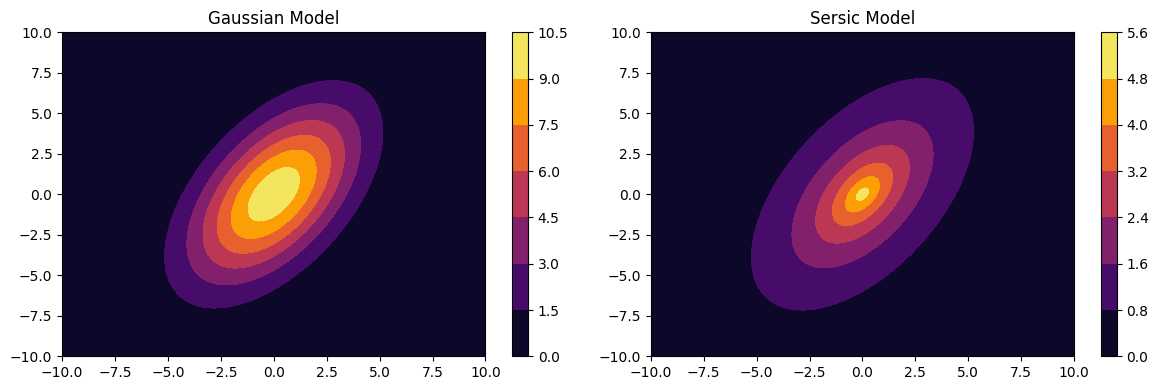

In [79]:
import matplotlib.pyplot as plt

# Esempio di utilizzo
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)


# gaussian.set_parameters_values([1,2,3,4,5,6])
gaussian.set_parameters_values(
    {
        "amp": 10,
        "x0": 0,
        "y0": 0,
        "sigma_x": 4,
        "sigma_y": 2,
        "theta": np.pi / 3,
    }
)

sersic.set_parameters_values(
    {"amp": 1, "re": 7, "ellip": 0.5, "theta": np.pi / 3, "n": 1, "x0": 0, "y0": 0}
)

gaussian_values = gaussian(
  [  X, Y, ]
)  # X, Y, amp=23.4, sigma_x=7.4) # *[a,b,c...]

sersic_values = sersic([X, Y])


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Gaussian Model")
plt.contourf(X, Y, gaussian_values, cmap="inferno")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Sersic Model")
plt.contourf(X, Y, sersic_values, cmap="inferno")
plt.colorbar()


plt.tight_layout()
plt.show()

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Gaussian_test', 'Sersic_di_sto_cazzo']
GRID VARIABLES: ['x', 'y']
LOGIC: (Gaussian_test [0] + Sersic_di_sto_cazzo [1])
FREE PARAMS: 13
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    amp_0           10.00      0          (-inf, inf)         
1    x0_0            0.00       0          (-inf, inf)         
2    y0_0            0.00       0          (-inf, inf)         
3    sigma_x_0       4.00       0          (-inf, inf)         
4    sigma_y_0       2.00       0          (-inf, inf)         
5    theta_0         1.05       0          (-inf, inf)         
6    amp_1           1.00       0          (-inf, inf)         
7    re_1            7.00       0          (-inf, inf)         
8    n_1             1.00       0          (-inf, inf)         
9    x0_1            0.0

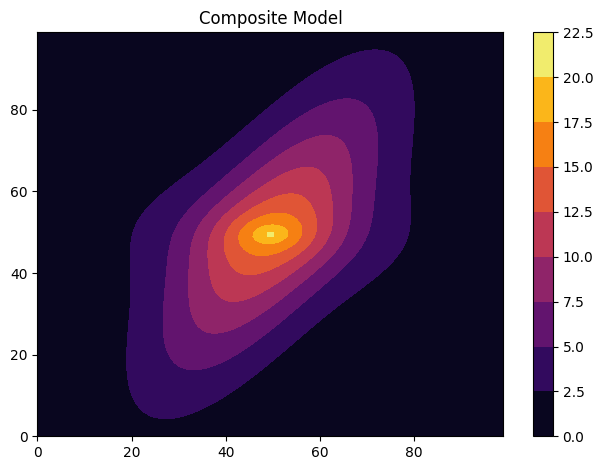

In [80]:
composite = gaussian + sersic

# CompositeModel(gaussian, sersic, "+")

# composite.freeze_parameters(1, 2, 3, "theta_2", amp_0=8.33)
# print(gaussian(0,0) + sersic(0,0), composite(0,0))

composite.unfreeze_parameters()

# composite.set_parameters_values({'ellip_1': .22, 'x0_0':3})    #eq a ellip_1 = 22, amp_0 = 1
composite_values = composite.evaluate(
    X,
    Y,
    x0_0=0,
    re_1=10,
    sigma_x_0=6,
    n_1=1.4,
    theta_1=np.pi,
)  # supporta anche kwargs isolate ora yeee (sovrascrivono gli args)
# supporta anche kwargs isolate ora yeee (sovrascrivono gli args)

# composite.set_parameters_bounds({"amp_0": (0, 20)})
# composite.set_parameters_bounds(re_1=(0, 10))
print(composite)
print(composite.n_inputs, composite.n_outputs, composite.n_dim)
plt.title("Composite Model")
plt.contourf(composite_values, cmap="inferno")
plt.colorbar()

plt.tight_layout()
plt.show()

In [81]:
composite -= sersic
print(composite)

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Gaussian_test', 'Sersic_di_sto_cazzo', 'Sersic_di_sto_cazzo']
GRID VARIABLES: ['x', 'y']
LOGIC: ((Gaussian_test [0] + Sersic_di_sto_cazzo [1]) - Sersic_di_sto_cazzo [2])
FREE PARAMS: 20
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    amp_0           10.00      0          (-inf, inf)         
1    x0_0            0.00       0          (-inf, inf)         
2    y0_0            0.00       0          (-inf, inf)         
3    sigma_x_0       4.00       0          (-inf, inf)         
4    sigma_y_0       2.00       0          (-inf, inf)         
5    theta_0         1.05       0          (-inf, inf)         
6    amp_1           1.00       0          (-inf, inf)         
7    re_1            7.00       0          (-inf, inf)         
8    n_1             1.00       0    

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Gaussian1D', 'Gaussian1D']
GRID VARIABLES: ['x']
LOGIC: (Gaussian1D [0] + Gaussian1D [1])
FREE PARAMS: 6
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    amp_0           18.00      0          (-inf, inf)         
1    x0_0            2.00       0          (-inf, inf)         
2    stddev_0        0.20       0          (-inf, inf)         
3    amp_1           15.00      0          (-inf, inf)         
4    x0_1            5.00       0          (-inf, inf)         
5    stddev_1        1.20       0          (-inf, inf)         

100
11
0.0025478501484211603


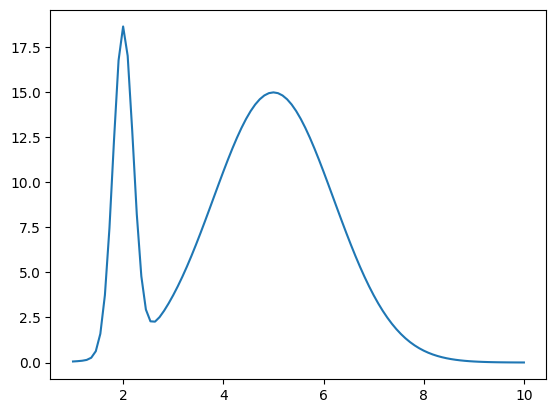

In [82]:
class Line(Fittable1D):
    def evaluate(self, x, x0, a, b):
        return a * (x - x0) + b


class PowerLaw(Fittable1D):
    def evaluate(self, x, alpha):
        return x**alpha


class Gaussian1D(Fittable1D):
    def evaluate(self, x, amp, x0, stddev):
        """
        Gaussian1D model function.
        """
        return amp * np.exp(-0.5 * (x - x0) ** 2 / stddev**2)


line = Line(b=1, a=1, x0=0)
powelaw = PowerLaw(alpha=2)  # adesso keywards supportate per la creazione del modello

comp = Gaussian1D(stddev=0.2, x0=2, amp=18) + Gaussian1D(stddev=1.2, x0=5, amp=15)

grid = np.linspace(1, 10, 100)

print(comp)

plt.plot(grid, comp([grid]))
print(powelaw([10]))
print(line([10]))
print(comp([10]))